### Import Library 

In [29]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [30]:
pip install PCA

Note: you may need to restart the kernel to use updated packages.


In [31]:
pip install plotly.express 

Note: you may need to restart the kernel to use updated packages.


In [32]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px

In [33]:
df = pd.read_csv('../Pertemuan4/dataHospital.csv')
df.head()

,id,nama,propinsi,kab,alamat,jenis,kelas,status_blu,kepemilikan,median_total_tempat_tidur,total_tempat_tidur,median_total_tenaga,total_layanan,total_tenaga_kerja
0,1110053,RS Arun Lhokseumawe,Aceh,Kota Lhokseumawe,Jl. Plaju Komplek Perumahan PT Arun Batuphat T...,Rumah Sakit Umum,C,Non BLU/BLUD,SWASTA/LAINNYA,218,218,328,36,328
1,1106014,RS Umum Fandika,Aceh,Aceh Tengah,Jl. Terminal Simpang Wariji Blangkolak 1 Kec. ...,Rumah Sakit Umum,D,Non BLU/BLUD,SWASTA/LAINNYA,45,45,45,15,45
2,1171110,RS Umum Daerah Meuraxa,Aceh,Kota Banda Aceh,Jl. Soekarno Hatta Km. 2 Desa Mibo Kecamatan B...,Rumah Sakit Umum,B,BLUD,Pemkot,310,310,487,77,487
3,1171163,RS Gigi Mulut Universitas Syiah Kuala,Aceh,Kota Banda Aceh,Jl. Prof A. Madjid Ibrahim I No. 5 Banda Aceh ...,Rumah Sakit Khusus Gigi dan Mulut,B,BLU,Kementerian Lain,11,11,182,24,0
4,1102027,RS Umum Daerah Kota Subulussalam,Aceh,Kota Subulussalam,Jl. Hamzah Fansyuri (Subulussalam-Rundeng) Kec...,Rumah Sakit Umum,C,BLUD,Pemkot,189,189,537,34,537


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3155 entries, 0 to 3154
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   id                         3155 non-null   int64 
 1   nama                       3155 non-null   object
 2   propinsi                   3155 non-null   object
 3   kab                        3155 non-null   object
 4   alamat                     3155 non-null   object
 5   jenis                      3155 non-null   object
 6   kelas                      3155 non-null   object
 7   status_blu                 3155 non-null   object
 8   kepemilikan                3155 non-null   object
 9   median_total_tempat_tidur  3155 non-null   int64 
 10  total_tempat_tidur         3155 non-null   int64 
 11  median_total_tenaga        3155 non-null   int64 
 12  total_layanan              3155 non-null   int64 
 13  total_tenaga_kerja         3155 non-null   int64 
dtypes: int64

In [35]:
print(f"Jenis: \n {df['jenis'].unique()}\n")
print(f"Kelas: \n {df['kelas'].unique()}\n")
print(f"status_blu: \n {df['status_blu'].unique()}\n")
print(f"Kepemilikan: \n {df['kepemilikan'].unique()}\n")

Jenis: 
 ['Rumah Sakit Umum' 'Rumah Sakit Khusus Gigi dan Mulut'
 'Rumah Sakit Khusus Ibu dan Anak' 'Rumah Sakit Khusus Jiwa'
 'Rumah Sakit Khusus Bedah' 'Rumah Sakit Khusus Mata'
 'Rumah Sakit Khusus Paru' 'Rumah Sakit Khusus Ginjal'
 'Rumah Sakit Khusus Stroke' 'Rumah Sakit Khusus THT-KL'
 'Rumah Sakit Khusus Kanker' 'Rumah Sakit Khusus Infeksi'
 'Rumah Sakit Khusus Jantung' 'Rumah Sakit Khusus Otak'
 'Rumah Sakit Ketergantungan Obat' 'Rumah Sakit Khusus Orthopedi'
 'RS Kapal/Bergerak']

Kelas: 
 ['C' 'D' 'B' 'D PRATAMA' 'A' 'Belum Ditetapkan' 'Rumah Sakit Umum'
 'Rumah Sakit Khusus Jiwa']

status_blu: 
 ['Non BLU/BLUD' 'BLUD' 'BLU' 'D' 'A' 'C' 'D PRATAMA']

Kepemilikan: 
 ['SWASTA/LAINNYA' 'Pemkot' 'Kementerian Lain' 'Pemkab' 'Perusahaan'
 'Organisasi Sosial' 'POLRI' 'TNI AD' 'TNI AL' 'BUMN' 'Pemprop'
 'Perorangan' 'Organisasi Katholik' 'Organisasi Protestan' 'Kemkes'
 'TNI AU' 'Organisasi Islam' 'Organisasi Budha' 'BLUD' 'BLU'
 'Non BLU/BLUD' 'Organisasi Hindu']



### Cleaning

In [36]:
df[df['kelas'] == 'D PRATAMA'][['nama', 'kelas', 'jenis']]

,nama,kelas,jenis
25,RS Umum Daerah Type D Pratama T. Cut Ali,D PRATAMA,Rumah Sakit Umum
32,RS Umum Daerah dr. Muchtar Hasbi,D PRATAMA,Rumah Sakit Umum
99,RS Pratama Kab. Nias Barat,D PRATAMA,Rumah Sakit Umum
244,RS Pratama Lologolu Soguna Ba Zato,D PRATAMA,Rumah Sakit Umum
312,RS Umum Daerah Kamang Baru,D PRATAMA,Rumah Sakit Umum
...,...,...,...
3117,RS Umum Daerah Pratama Dogiyai,D PRATAMA,Rumah Sakit Umum
3138,RS Umum Daerah Ilaga,D PRATAMA,Rumah Sakit Umum
3144,RS Bergerak Kab. Boven Digoel,D PRATAMA,Rumah Sakit Umum
3146,RS Umum Daerah Karubaga,D PRATAMA,Rumah Sakit Umum


In [37]:
df[df['kelas'] == 'Rumah Sakit Khusus Jiwa'][['nama', 'kelas', 'jenis']]

,nama,kelas,jenis
1746,RS Khusus Jiwa Puri Nirmala,Rumah Sakit Khusus Jiwa,Rumah Sakit Umum


In [38]:
df.loc[
    df['nama'] == 'RS Umum Daerah Kepulauan Seribu',
    'kelas'
] = 'D'

df.loc[
    df['nama'] == 'RS Umum Pusat Dr. Soeradji Tirtonegoro',
    'kelas'
] = 'A'

df.loc[
    df['nama'] == 'RS Umum Daerah Kawera',
    'kelas'
] = 'D PRATAMA'

df.loc[
    df['nama'] == 'RS Sakit Khusus Jiwa',
    'kelas'
] = 'C'

In [39]:
kelas_mapping = {
    'A': 4,
    'B': 3,
    'C': 2,
    'D': 1,
    'D PRATAMA': 0,
    'Belum Ditetapkan': -1
}

df['kelas'] = df['kelas'].map(kelas_mapping)

In [40]:
# Cek daftar kolom yang tersedia
print(df.columns)

Index(['id', 'nama', 'propinsi', 'kab', 'alamat', 'jenis', 'kelas',
       'status_blu', 'kepemilikan', 'median_total_tempat_tidur',
       'total_tempat_tidur', 'median_total_tenaga', 'total_layanan',
       'total_tenaga_kerja'],
      dtype='object')


In [41]:
df= pd.get_dummies(
    df,
    columns=['jenis', 'kepemilikan'],
)

In [42]:
df.head()

,id,nama,propinsi,kab,alamat,kelas,status_blu,median_total_tempat_tidur,total_tempat_tidur,median_total_tenaga,...,kepemilikan_POLRI,kepemilikan_Pemkab,kepemilikan_Pemkot,kepemilikan_Pemprop,kepemilikan_Perorangan,kepemilikan_Perusahaan,kepemilikan_SWASTA/LAINNYA,kepemilikan_TNI AD,kepemilikan_TNI AL,kepemilikan_TNI AU
0,1110053,RS Arun Lhokseumawe,Aceh,Kota Lhokseumawe,Jl. Plaju Komplek Perumahan PT Arun Batuphat T...,2.0,Non BLU/BLUD,218,218,328,...,False,False,False,False,False,False,True,False,False,False
1,1106014,RS Umum Fandika,Aceh,Aceh Tengah,Jl. Terminal Simpang Wariji Blangkolak 1 Kec. ...,1.0,Non BLU/BLUD,45,45,45,...,False,False,False,False,False,False,True,False,False,False
2,1171110,RS Umum Daerah Meuraxa,Aceh,Kota Banda Aceh,Jl. Soekarno Hatta Km. 2 Desa Mibo Kecamatan B...,3.0,BLUD,310,310,487,...,False,False,True,False,False,False,False,False,False,False
3,1171163,RS Gigi Mulut Universitas Syiah Kuala,Aceh,Kota Banda Aceh,Jl. Prof A. Madjid Ibrahim I No. 5 Banda Aceh ...,3.0,BLU,11,11,182,...,False,False,False,False,False,False,False,False,False,False
4,1102027,RS Umum Daerah Kota Subulussalam,Aceh,Kota Subulussalam,Jl. Hamzah Fansyuri (Subulussalam-Rundeng) Kec...,2.0,BLUD,189,189,537,...,False,False,True,False,False,False,False,False,False,False


### Feature Selection

In [43]:
df_cluster = df.drop(columns=['id', 'nama', 'propinsi', 'kab', 'alamat', 'status_blu'])

### Normalisasi

In [50]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

### Modelling

In [64]:
from sklearn.impute import SimpleImputer

# Isi nilai NaN dengan mean
imputer = SimpleImputer(strategy='mean')
X_scaled_clean = imputer.fit_transform(X_scaled)

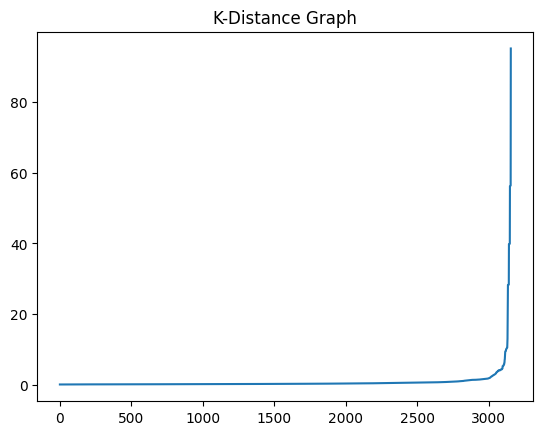

In [65]:
neighbors = NearestNeighbors(n_neighbors=5)
distances, _ = neighbors.fit(X_scaled).kneighbors(X_scaled_clean)

distances = np.sort(distances[:, 4])

plt.plot(distances)
plt.title('K-Distance Graph')
plt.show()

In [66]:
best_score = -1

for eps in np.arange(2, 5.1, 0.1):

    for min_samples in range(120, 140):

        model = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = model.fit_predict(X_scaled)

        # cek jumlah cluster
        if len(set(labels)) > 2:

            score = silhouette_score(X_scaled, labels)

            # Simpan model terbaik
            if score > best_score:
                best_score = score
                best_model = model
                best_labels = labels
                best_eps = eps
                best_min_samples = min_samples
print(f"Best Silhouette Score: {best_score}")
print(f"Best eps: {best_eps}")
print(f"Best min_samples: {best_min_samples}")

Best Silhouette Score: 0.2706199149145734
Best eps: 2.7000000000000006
Best min_samples: 128


### Evaluasi

In [67]:
print(f"Best EPS:", best_eps)
print(f"Best min_samples:", best_min_samples)

print(
    "Best Silhouette Score:",
    round(best_score, 4)
)

Best EPS: 2.7000000000000006
Best min_samples: 128
Best Silhouette Score: 0.2706


In [68]:
unique, counts = np.unique(best_labels, return_counts=True)
for label, count in zip(unique, counts):
    if label == -1:
        print(f"Noise: {count} titik")
    else:
        print(f"Cluster {label}: {count} titik")

Noise: 1055 titik
Cluster 0: 665 titik
Cluster 1: 643 titik
Cluster 2: 395 titik
Cluster 3: 152 titik
Cluster 4: 244 titik


In [70]:
dbscan = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples
)

clusters = dbscan.fit_predict(X_scaled_clean)
df['cluster'] = clusters

ValueError: Length of values (3154) does not match length of index (3155)

In [71]:
print("Jumlah baris di DF asli:", len(df))
print("Jumlah hasil klaster:", len(clusters))

Jumlah baris di DF asli: 3155
Jumlah hasil klaster: 3154


In [72]:
cluster_summary = df.groupby('cluster')[[
    'total_tempat_tidur',
    'total_layanan',
    'total_tenaga_kerja'
]].mean()

print(cluster_summary)

KeyError: 'cluster'

In [ ]:
# PCA 
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Buat dataframe sederhana
df_plot = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'PC3': X_pca[:, 2],
    'cluster': df['cluster']
})

# 3D interactive plot
fig = px.scatter_3d(
    df_plot,
    x='PC1',
    y='PC2',
    z='PC3',
    color='cluster',
    title='Visualisasi Klaster dengan PCA'
)